In [1]:
import os
import numpy as np
import pandas as pd
import shutil
import cv2
import random
import matplotlib.pyplot as plt
import copy
import wandb


In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("wandb_api")

In [3]:
wandb.login(key = secret_value_0)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: deeptaran2004bti (deeptaran2004bti-indian-institute-of-technology-kanpur). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [4]:
bs = ' '
class_id = 0
newline = '\n'
extension = '.txt'


In [5]:
curr_path = os.getcwd()
img_train_path = os.path.join(curr_path, "images", "train")
img_val_path = os.path.join(curr_path, "images", "validation")
img_test_path = os.path.join(curr_path, "images", "test")

label_train_path = os.path.join(curr_path, "labels", "train")
label_val_path = os.path.join(curr_path, "labels", "validation")
label_test_path = os.path.join(curr_path, "labels", "test")

In [6]:
data_path = "/kaggle/input/human-faces-object-detection"
labels_path = os.path.join(curr_path, "face_labels")

In [7]:
os.makedirs(labels_path)

In [8]:
os.listdir(data_path)

['faces.csv', 'images']

In [9]:
img_path = os.path.join(data_path, "images")
raw_annotations_path = os.path.join(data_path, 'faces.csv')

In [10]:
face_list = os.listdir(img_path)

In [11]:
face_list[:5]

['00002129.jpg',
 '00001760.jpg',
 '00001158.jpg',
 '00001981.jpg',
 '00000503.jpg']

In [12]:
data_len = len(face_list)
data_len

2204

In [13]:
face_list[:5]

['00002129.jpg',
 '00001760.jpg',
 '00001158.jpg',
 '00001981.jpg',
 '00000503.jpg']

In [14]:
train_split = 0.8
val_split = 0.1
test_split = 0.1

In [15]:
img_train_list = face_list[:int (data_len*train_split)]
img_val_list = face_list[int(data_len* train_split): int(data_len*(train_split+val_split))]
img_test_list = face_list[int(data_len* (train_split+ val_split)):]

In [16]:
img_test_list[:5]

['00000120.jpg',
 '00000824.jpg',
 '00001547.jpg',
 '00000506.jpg',
 '00000441.jpg']

In [17]:
len(img_train_list), len(img_val_list), len(img_test_list)

(1763, 220, 221)

In [18]:
def change_extension(file):
    basename = os.path.splitext(file)[0]
    filename = basename + extension
    return filename

In [19]:
label_train_list = list(map(change_extension, img_train_list))
label_val_list = list(map(change_extension, img_val_list))
label_test_list = list(map(change_extension, img_test_list))


In [20]:
len(label_train_list), len(label_val_list), len(label_test_list)

(1763, 220, 221)

In [21]:
label_test_list[:5]

['00000120.txt',
 '00000824.txt',
 '00001547.txt',
 '00000506.txt',
 '00000441.txt']

In [22]:
raw_annotations = pd.read_csv(raw_annotations_path)
raw_annotations.head()

,image_name,width,height,x0,y0,x1,y1
0,00001722.jpg,1333,2000,490,320,687,664
1,00001044.jpg,2000,1333,791,119,1200,436
2,00001050.jpg,667,1000,304,155,407,331
3,00001736.jpg,626,417,147,14,519,303
4,00003121.jpg,626,418,462,60,599,166


In [23]:
raw_annotations['x_centre'] = 0.5*(raw_annotations["x0"] + raw_annotations['x1'])
raw_annotations['y_centre'] = 0.5*(raw_annotations["y0"] + raw_annotations['y1'])
raw_annotations['bb_width'] = (raw_annotations["x1"] - raw_annotations['x0'])
raw_annotations['bb_height'] = (raw_annotations["y1"] - raw_annotations['y0'])

In [24]:
raw_annotations.head()

,image_name,width,height,x0,y0,x1,y1,x_centre,y_centre,bb_width,bb_height
0,00001722.jpg,1333,2000,490,320,687,664,588.5,492.0,197,344
1,00001044.jpg,2000,1333,791,119,1200,436,995.5,277.5,409,317
2,00001050.jpg,667,1000,304,155,407,331,355.5,243.0,103,176
3,00001736.jpg,626,417,147,14,519,303,333.0,158.5,372,289
4,00003121.jpg,626,418,462,60,599,166,530.5,113.0,137,106


In [25]:
raw_annotations["x_scaled"] = raw_annotations["x_centre"]/ raw_annotations['width']
raw_annotations["width_scaled"] = raw_annotations["bb_width"]/ raw_annotations['width']
raw_annotations["y_scaled"] = raw_annotations["y_centre"]/ raw_annotations['height']
raw_annotations["height_scaled"] = raw_annotations["bb_height"]/ raw_annotations['height']


In [26]:
raw_annotations.head()

,image_name,width,height,x0,y0,x1,y1,x_centre,y_centre,bb_width,bb_height,x_scaled,width_scaled,y_scaled,height_scaled
0,00001722.jpg,1333,2000,490,320,687,664,588.5,492.0,197,344,0.441485,0.147787,0.246000,0.172000
1,00001044.jpg,2000,1333,791,119,1200,436,995.5,277.5,409,317,0.497750,0.204500,0.208177,0.237809
2,00001050.jpg,667,1000,304,155,407,331,355.5,243.0,103,176,0.532984,0.154423,0.243000,0.176000
3,00001736.jpg,626,417,147,14,519,303,333.0,158.5,372,289,0.531949,0.594249,0.380096,0.693046
4,00003121.jpg,626,418,462,60,599,166,530.5,113.0,137,106,0.847444,0.218850,0.270335,0.253589


In [27]:
len(raw_annotations['image_name'].unique())

2204

'**groupby**' used when there are more than one object to detect in one image

In [28]:
imgs = raw_annotations.groupby('image_name')

In [29]:
for image in imgs:
    img_df = imgs.get_group(image[0])
    basename = os.path.splitext(image[0])[0]
    txt_file = basename + extension
    filepath = os.path.join(labels_path, txt_file)

    lines= []
    i = 1
    for index, row in img_df.iterrows():
        if i!= len(img_df):
            line = str(class_id) + bs + str(row["x_scaled"]) + bs + str(row["y_scaled"]) + bs + str(row["width_scaled"]) + bs + str(row["height_scaled"]) + newline
            lines.append(line)
        else:
            line = str(class_id) + bs + str(row["x_scaled"]) + bs + str(row["y_scaled"]) + bs + str(row["width_scaled"]) + bs + str(row["height_scaled"])
            lines.append(line)
        i+=1
    with open(filepath, "w") as file:
        file.writelines(lines)

In [30]:
os.listdir(labels_path)[:5]

['00002219.txt',
 '00000411.txt',
 '00002592.txt',
 '00002624.txt',
 '00003390.txt']

In [31]:
random_file = os.path.join(labels_path, os.listdir(labels_path)[10])

with open(random_file, 'r') as f:
    content = f.read()
content


'0 0.5259336099585062 0.3706170154933406 0.104149377593361 0.12150040771948899'

In [32]:
def_size = 640

In [33]:
len(os.listdir(labels_path))

2204

In [34]:
def move_files(data_list, source_path, dest_path):
    i = 0
    for file in data_list:
        filepath = os.path.join(source_path, file)
        dest_path = os.path.join(data_path, dest_path)
        if not os.path.isdir(dest_path):
            os.makedirs(dest_path)
        shutil.move(filepath, dest_path)
        i += 1

    print("number of file transfered: ", i)

In [35]:
def move_imgs(data_list, source_path, dest_path):
    i = 0
    for file in data_list:
        filepath = os.path.join(source_path, file)
        dest_path = os.path.join(data_path, dest_path)

        if not os.path.isdir(dest_path):
            os.makedirs(dest_path)
        final_img_path = os.path.join(dest_path, file)
        img_resized = cv2.resize(cv2.imread(filepath), (def_size, def_size))
        cv2.imwrite(final_img_path, img_resized)
        i += 1
    print("number of files transfered: ", i)

In [36]:
move_imgs(img_train_list, img_path, img_train_path)

number of files transfered:  1763


In [37]:
move_imgs(img_val_list, img_path, img_val_path)

number of files transfered:  220


In [38]:
move_imgs(img_test_list, img_path, img_test_path)

number of files transfered:  221


In [39]:
move_files(label_train_list, labels_path, label_train_path)

number of file transfered:  1763


In [40]:
move_files(label_val_list, labels_path, label_val_path)

number of file transfered:  220


In [41]:
move_files(label_test_list, labels_path, label_test_path)

number of file transfered:  221


In [42]:
len(os.listdir(labels_path))

0

In [43]:
shutil.rmtree(labels_path)

In [44]:
ln_1 = "# Train/val/test sets" + newline
ln_2 = 'train: ' + "'" + img_train_path + "'"+newline
ln_3 = 'val: '+"'"+img_val_path+"'"+newline
ln_4 = "test: "+ "'"+img_test_path+"'"+newline
ln_5 = newline
ln_6 = "# Classes"+newline
ln_7 = "names:"+newline
ln_8 = " 0: face"
config_lines = [ln_1, ln_2, ln_3, ln_4, ln_5, ln_6, ln_7, ln_8]

In [45]:
config_path = os.path.join(curr_path, "config.yaml")
config_path

'/kaggle/working/config.yaml'

In [46]:
with open(config_path, "w") as f:
    f.writelines(config_lines)

In [47]:
def get_bbox(text_file_path):
    bbox_list = []
    with open(text_file_path, "r") as file:
        for line in file:
            _, x_centre, y_centre, width, height = line.strip().split(" ")

            x1 = (float(x_centre) + float(width)/2)*def_size
            x0 = (float(x_centre) - float(width)/2)*def_size
            y1 = (float(y_centre) + float(height)/2)*def_size
            y0 = (float(y_centre) - float(height)/2)*def_size

            vertices=np.array([[int(x0), int(y0)], [int(x1), int(y0)], [int(x1),int(y1)], [int(x0),int(y1)]])
            bbox_list.append(vertices)

    return tuple(bbox_list)

In [48]:
red = (255,0 ,0)

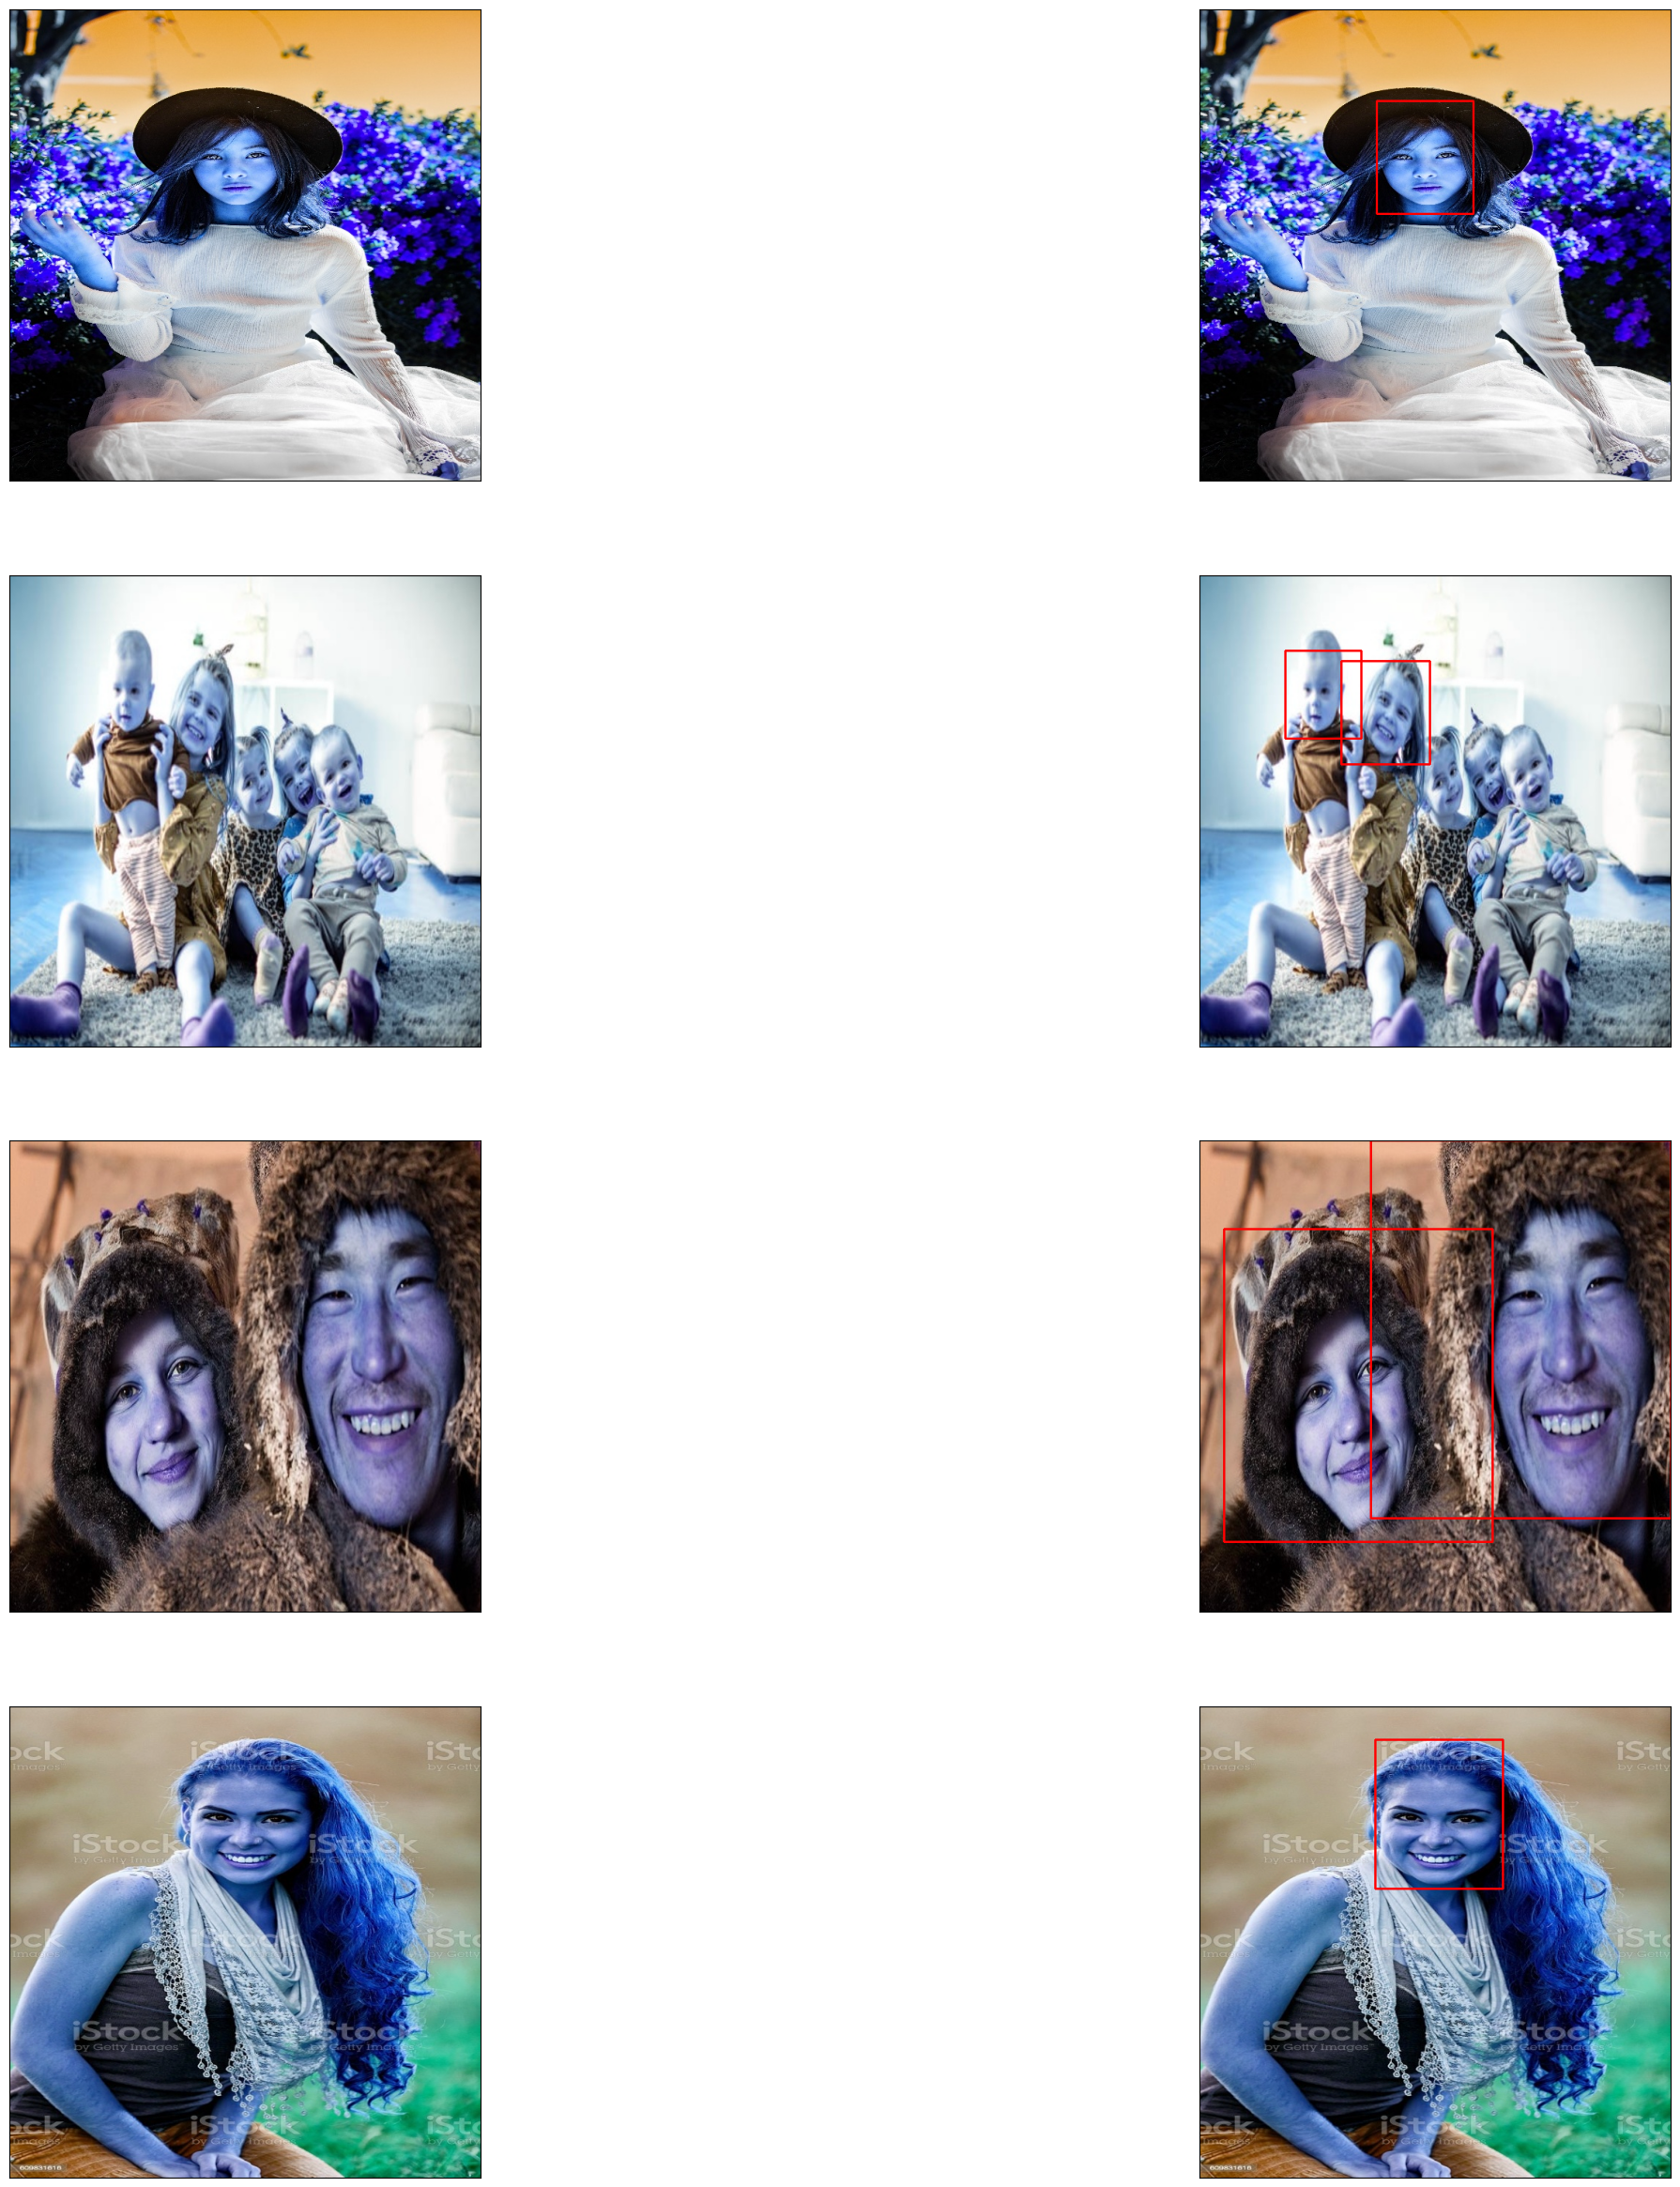

In [49]:
plt.figure(figsize = (30, 30))

for i in range(1, 8, 2):
    k = random.randint(0, len(img_train_list)-1)
    img_path = os.path.join(img_train_path, img_train_list[k])
    label_path =  os.path.join(label_train_path, label_train_list[k])
    bbox = get_bbox(label_path)
    image = cv2.imread(img_path)
    image_copy = copy.deepcopy(image)
    ax = plt.subplot(4,2,i)
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])

    cv2.drawContours(image_copy, bbox, -1, red, 2)
    ax = plt.subplot(4, 2, i+1)
    plt.imshow(image_copy)
    plt.xticks([])
    plt.yticks([])
    

In [50]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 24.4 MB/s eta 0:00:00


In [51]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [52]:
model = YOLO("yolov8n.yaml").load("yolov8n.pt")

100%|██████████| 6.25M/6.25M [00:00<00:00, 108MB/s]

Transferred 355/355 items from pretrained weights


In [53]:
results = model.train(data = config_path, epochs =100, resume = True, iou = 0.5, conf = 0.001)

Ultralytics 8.3.70 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.yaml, data=/kaggle/working/config.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=yolov8n.pt, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=None, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=0.001, iou=0.5, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show

100%|██████████| 755k/755k [00:00<00:00, 25.8MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 122MB/s]


AMP: checks passed ✅


...


100 epochs completed in 0.617 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.3MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.70 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv8n summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.87it/s]


                   all        220        329      0.917      0.933      0.977      0.831


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.3ms preprocess, 2.0ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to runs/detect/train


In [54]:
!zip -r results.zip /kaggle/working/runs/detect/train

  adding: kaggle/working/runs/detect/train/ (stored 0%)
  adding: kaggle/working/runs/detect/train/F1_curve.png (deflated 19%)
  adding: kaggle/working/runs/detect/train/train_batch9990.jpg (deflated 11%)
  adding: kaggle/working/runs/detect/train/train_batch1.jpg (deflated 3%)
  adding: kaggle/working/runs/detect/train/val_batch0_pred.jpg (deflated 6%)
  adding: kaggle/working/runs/detect/train/R_curve.png (deflated 18%)
  adding: kaggle/working/runs/detect/train/train_batch9991.jpg (deflated 11%)
  adding: kaggle/working/runs/detect/train/train_batch2.jpg (deflated 3%)
  adding: kaggle/working/runs/detect/train/events.out.tfevents.1738608910.f8d33e2ccb9a.18.0 (deflated 87%)
  adding: kaggle/working/runs/detect/train/results.csv (deflated 62%)
  adding: kaggle/working/runs/detect/train/labels_correlogram.jpg (deflated 38%)
  adding: kaggle/working/runs/detect/train/confusion_matrix.png (deflated 39%)
  adding: kaggle/working/runs/detect/train/train_batch0.jpg (deflated 5%)
  adding: k

In [55]:
torch.save(model , "yolo.pth")

NameError: name 'torch' is not defined

In [ ]:
import pickle

with open("yolo.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
plt.figure(figsize=  (30, 30))
training_result_path = os.path.join(curr_path, "runs", "detect", "train")
results_png = cv2.imread(os.path.join(training_result_path, "results.png"))
plt.imshow(results_png)

In [ ]:
def evaluate_map50(trained_model, data_path, dataset = "val"):
    metrics = trained_model.val(data= data_path, split= dataset)
    map50 = round(metrics.box.map50, 3)
    print("the mAP of model on{0} dataset is {1}".format(dataset, map50))
    return metrics, map50

In [ ]:
def display_curves(root_path):
    plt.figure(figsize=(50,50))
    
    #displaying p curve
    p_curve=cv2.imread(os.path.join(root_path,'P_curve.png'))
    ax=plt.subplot(5,1,1)
    plt.imshow(p_curve)
    
    #displaying r curve
    r_curve=cv2.imread(os.path.join(root_path,'R_curve.png'))
    ax=plt.subplot(5,1,2)
    plt.imshow(r_curve)
    
    #displaying pr curve
    pr_curve=cv2.imread(os.path.join(root_path,'PR_curve.png'))
    ax=plt.subplot(5,1,3)
    plt.imshow(pr_curve)
    
    #displaying f1 curve
    f1_curve=cv2.imread(os.path.join(root_path,'F1_curve.png'))
    ax=plt.subplot(5,1,4)
    plt.imshow(f1_curve)
    
    #displaying confusion matrix
    confusion_matrix=cv2.imread(os.path.join(root_path,'confusion_matrix.png'))
    ax=plt.subplot(5,1,5)
    plt.imshow(confusion_matrix)


In [ ]:
train_metrics, train_map50 = evaluate_map50(model, config_path, dataset= 'train')

In [ ]:
train_path = os.path.join(curr_path, "runs", "detect", "val")

In [ ]:
# display_curves(train_path)

In [ ]:
plt.figure(figsize=(60,60))
m=random.randint(0, 150) # Selecting random image number
for i in range(1,8,2):
    test_image=os.path.join(img_test_path, os.listdir(img_test_path)[m])
    ax=plt.subplot(4,2,i)
    
    # Display actual image
    plt.imshow(cv2.imread(test_image)) 
    plt.xticks([])
    plt.yticks([])
    plt.title("Actual image", fontsize = 40)
    
    # Predict 
    res = model(test_image)
    res_plotted = res[0].plot()
    ax=plt.subplot(4,2,i+1)
    
    # Display image with predictions
    plt.imshow(res_plotted)
    plt.title("Image with predictions", fontsize = 40)
    plt.xticks([])
    plt.yticks([])
    m=m+1

In [ ]:
res[0].plot()